# CLAMPfull 80/20 held-out validation

The goal is to test whether an LV selected from training samples also tracks the same cell type in unseen pseudobulk samples. Samples from the same donor remain in the same partition whenever `patient_info.csv` provides `donor_id`; otherwise pseudobulk samples are split directly.

For cell type $c$, select its LV using **training data only**:

$$k_c^* = rg\max_k\; \operatorname{cor}(B_{\mathrm{train},k}, p_{\mathrm{train},c}).$$

Project held-out samples into the fitted training model and evaluate that same LV:

$$r_{\mathrm{test},c} = \operatorname{cor}(B_{\mathrm{test},k_c^*}, p_{\mathrm{test},c}).$$

No LV is reselected on the test samples and no classifier is fitted. The primary result is held-out Pearson correlation per cell type, summarized across datasets.

## Parameters

In [1]:
OUT_DIR <- 'output/03_model_biology/02_pseudobulk/01_holdout80'
DATASETS <- 'Brain_Mathys2023,Brain_Xiong2023,Heart_Datar2026,PBMC_1k1k,PBMC_Perez2022,Lung_Sikkema2023'
DATA_ROOT <- 'data/pseudobulk'
SEED <- 42L
MAX_ITER <- 500L

In [2]:
# Parameters
DATASETS = "Brain_Mathys2023,Brain_Xiong2023,Heart_Datar2026,PBMC_1k1k,PBMC_Perez2022,Lung_Sikkema2023"


## Functions

In [3]:
suppressPackageStartupMessages({
  library(CLAMP); library(rsvd); library(data.table); library(here)
  library(ggplot2); library(dplyr)
})
source(here('scripts', 'pseudobulk', 'common.R'))

prepare_train_test <- function(train_counts, test_counts,
                               mean_cutoff = 0.5, var_cutoff = 0.1) {
  train_cpm <- CLAMP::cpmCLAMP(train_counts)
  prep <- CLAMP::preprocessCLAMP(train_cpm, mean_cutoff, var_cutoff)
  train_norm <- CLAMP::zscoreCLAMP(prep$Y_filtered, prep$rowStats)

  test_cpm <- CLAMP::cpmCLAMP(test_counts)
  genes <- intersect(rownames(prep$Y_filtered), rownames(test_cpm))
  test_norm <- CLAMP::zscoreCLAMP(test_cpm[genes, , drop = FALSE],
                                  prep$rowStats[genes, , drop = FALSE])
  list(train = train_norm[genes, , drop = FALSE],
       test = test_norm, row_stats = prep$rowStats[genes, , drop = FALSE])
}

fit_clampfull <- function(norm, max_iter = 500L) {
  svd_k <- floor((min(dim(norm)) - 1L) / 4L)
  if (svd_k < 2L) stop('Training split has too few samples for CLAMP')
  svdres <- rsvd::rsvd(norm, k = svd_k)
  log_d <- log(pmax(svdres$d, .Machine$double.eps))
  elbow <- if (length(log_d) > 1L) which.min(diff(log_d)) else 1L
  k <- min(max(as.integer(elbow * 2L), 2L), svd_k)
  pathways <- CLAMP::getGMT(
    'https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2025')
  names(pathways) <- paste0('BP_', names(pathways))
  prior <- CLAMP::getMatchedPathwayMat(
    CLAMP::gmtListToSparseMat(list(BP = pathways)), rownames(norm))
  base <- CLAMP::CLAMPbase(Y = norm, svdres = svdres, clamp_k = k, trace = FALSE)
  full <- CLAMP::CLAMPfull(Y = norm, svdres = svdres, priorMat = prior,
    clamp.base.result = base, clamp_k = k, max.iter = max_iter,
    use_cpp = TRUE, trace = FALSE)
  full$B <- as.data.frame(full$B); colnames(full$B) <- colnames(norm)
  full$Z <- as.data.frame(full$Z); rownames(full$Z) <- rownames(norm)
  full
}

select_training_lvs <- function(B, truth) {
  samples <- intersect(rownames(B), rownames(truth))
  B <- B[samples, , drop = FALSE]
  truth <- truth[samples, , drop = FALSE]
  B <- B[, apply(B, 2, var, na.rm = TRUE) > 0, drop = FALSE]
  scores <- cor(B, truth, use = 'pairwise.complete.obs', method = 'pearson')
  rows <- lapply(colnames(scores), function(ct) {
    values <- scores[, ct]
    lv <- names(which.max(values))
    data.frame(cell_type = ct, LV = lv, train_cor = unname(values[lv]),
               stringsAsFactors = FALSE)
  })
  do.call(rbind, rows)
}

make_split <- function(ds, ids, data_root, seed) {
  info_path <- file.path(data_root, ds, 'patient_info.csv')
  group <- setNames(ids, ids)
  split_unit <- 'sample'
  if (file.exists(info_path)) {
    info <- data.table::fread(info_path, data.table = FALSE)
    if (all(c('sample', 'donor_id') %in% names(info))) {
      donor <- setNames(as.character(info$donor_id), as.character(info$sample))
      mapped <- donor[ids]
      usable <- !is.na(mapped) & nzchar(mapped)
      group[usable] <- mapped[usable]
      split_unit <- 'donor_id'
    }
  }
  units <- sort(unique(unname(group)))
  if (length(units) < 2L) stop(ds, ': fewer than two split units')
  set.seed(seed)
  n_train <- min(length(units) - 1L, max(1L, floor(0.8 * length(units))))
  train_units <- sample(units, n_train, replace = FALSE)
  train_ids <- sort(ids[group[ids] %in% train_units])
  test_ids <- sort(setdiff(ids, train_ids))
  membership <- data.frame(dataset = ds, sample = ids,
    split_unit = split_unit, group_id = unname(group[ids]),
    split = ifelse(ids %in% train_ids, 'train', 'test'), seed = seed,
    stringsAsFactors = FALSE)
  list(train = train_ids, test = test_ids, membership = membership)
}

## Analysis and outputs

Running held-out validation: Brain_Mathys2023



Warning message in data.table::fread(path):
“Detected 80 column names but the data has 81 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


Warning message in data.table::fread(path):
“Detected 7 column names but the data has 8 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


Auto-detected name: GO_Biological_Process_2025



Using cached file for GO_Biological_Process_2025



...

Updating Z for CV



crossValidation



There are 4 LVs with AUC>0.70



There are 4 LVs with AUC>0.90



dataset,n_cell_types,median_test_pearson,mean_test_pearson
<chr>,<int>,<dbl>,<dbl>
Brain_Mathys2023,7,-0.06112115,0.2025583
Brain_Xiong2023,7,0.50133840,0.4553767
Heart_Datar2026,14,0.33070223,0.3601683
PBMC_1k1k,9,0.38679569,0.2814325
PBMC_Perez2022,4,0.27696071,0.2989694
Lung_Sikkema2023,11,0.29699528,0.3410771


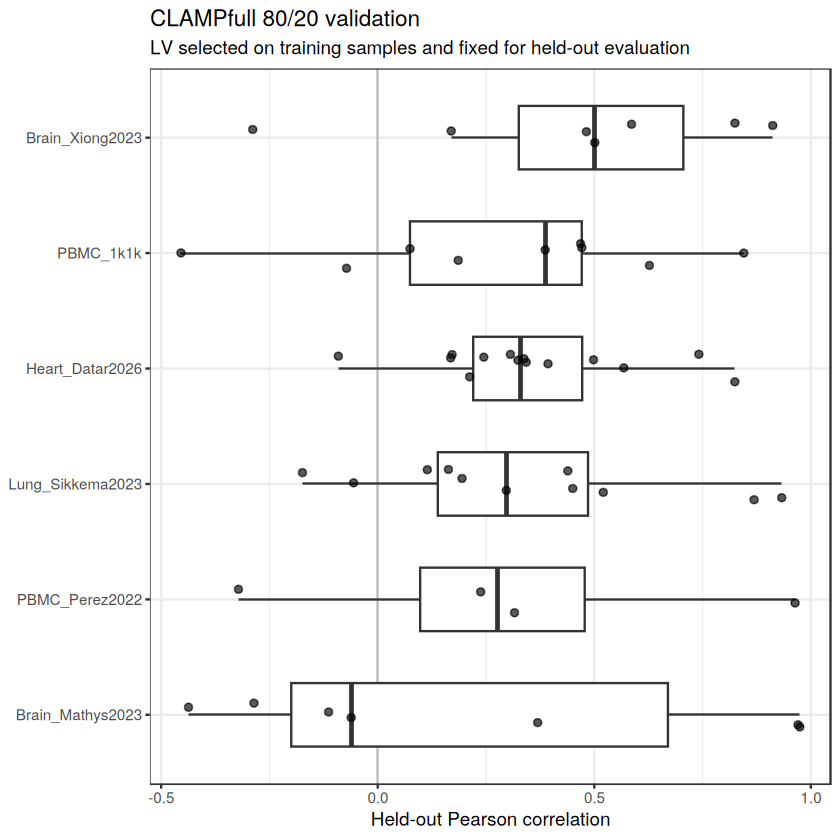

In [4]:
out_dir <- OUT_DIR
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
datasets <- strsplit(DATASETS, ',', fixed = TRUE)[[1]]
metrics <- list(); assignments <- list(); splits <- list(); values <- list()

for (ds in datasets) {
  message('Running held-out validation: ', ds)
  counts <- read_csv_matrix(file.path(DATA_ROOT, ds, 'bulk_expr.csv'))
  truth <- read_truth(file.path(DATA_ROOT, ds, 'truthFrac_v0.csv'))
  ids <- sort(intersect(colnames(counts), rownames(truth)))
  split <- make_split(ds, ids, DATA_ROOT, SEED)
  train_ids <- split$train; test_ids <- split$test
  splits[[ds]] <- split$membership

  prepared <- prepare_train_test(counts[, train_ids, drop = FALSE],
                                 counts[, test_ids, drop = FALSE])
  model <- fit_clampfull(prepared$train, MAX_ITER)
  train_B <- t(as.matrix(model$B))
  assignment <- select_training_lvs(train_B,
    truth[rownames(train_B), , drop = FALSE])
  assignment$dataset <- ds
  assignment$n_train <- length(train_ids)
  assignment$n_test <- length(test_ids)
  assignment$seed <- SEED
  assignments[[ds]] <- assignment

  model$Z <- as.matrix(model$Z[rownames(prepared$test), , drop = FALSE])
  projected <- CLAMP::projectCLAMP(CLAMPres = model, newdata = prepared$test)
  test_B <- t(as.matrix(projected))
  test_B <- test_B[test_ids, , drop = FALSE]

  for (i in seq_len(nrow(assignment))) {
    ct <- assignment$cell_type[i]; lv <- assignment$LV[i]
    actual <- truth[test_ids, ct]
    observed <- test_B[test_ids, lv]
    score <- suppressWarnings(cor(observed, actual,
      use = 'complete.obs', method = 'pearson'))
    metrics[[length(metrics) + 1L]] <- data.frame(
      dataset = ds, cell_type = ct, LV = lv,
      train_cor = assignment$train_cor[i], test_pearson = score,
      n_train = length(train_ids), n_test = length(test_ids), seed = SEED)
    values[[length(values) + 1L]] <- data.frame(
      dataset = ds, sample = test_ids, cell_type = ct, LV = lv,
      heldout_lv_score = observed, heldout_fraction = actual, seed = SEED)
  }
}

split_df <- rbindlist(splits)
assignment_df <- rbindlist(assignments)
metric_df <- rbindlist(metrics)
value_df <- rbindlist(values)
summary_df <- metric_df[, .(
  n_cell_types = .N,
  median_test_pearson = median(test_pearson, na.rm = TRUE),
  mean_test_pearson = mean(test_pearson, na.rm = TRUE)), by = dataset]

fwrite(split_df, file.path(out_dir, 'split_membership.csv'))
fwrite(assignment_df, file.path(out_dir, 'train_lv_assignments.csv'))
fwrite(metric_df, file.path(out_dir, 'heldout_metrics.csv'))
fwrite(value_df, file.path(out_dir, 'heldout_values.csv'))
fwrite(summary_df, file.path(out_dir, 'heldout_summary.csv'))

p_holdout <- ggplot(metric_df, aes(x = reorder(dataset, test_pearson, median),
                                    y = test_pearson)) +
  geom_hline(yintercept = 0, color = 'grey75') +
  geom_boxplot(outlier.shape = NA, width = 0.55) +
  geom_jitter(width = 0.14, alpha = 0.65, size = 1.6) +
  coord_flip() + theme_bw(base_size = 11) +
  labs(x = NULL, y = 'Held-out Pearson correlation',
       title = 'CLAMPfull 80/20 validation',
       subtitle = 'LV selected on training samples and fixed for held-out evaluation')
ggsave(file.path(out_dir, 'heldout_correlations.png'), p_holdout,
       width = 8, height = 5.5, dpi = 150)
print(p_holdout)
summary_df